## Análisis de datos - Clase 3
---

## Taller práctico parte 1 - análisis inicial de un dataset
---


Vamos a realizar una actividad con un dataset con datos del Servicio Meteorológico Nacional Argentino. El dataset contiene estadísticas climáticas normales (período 1991-2020).

Fuente: https://www.smn.gob.ar/descarga-de-datos

Consigna: identificar los valores faltantes y posibles causas.

Resumen de variables:
* estación, provincia, latitud, longitud, altitud, número y NroOACI (estos dos últimos identifican las estaciones)
* mes
* temperatura media, máxima y mínima
* humedad relativa
* velocidad del viento
* nubosidad total (en meteorología, la nubosidad se mide en octas (0, despejado - 8 completamente cubierto), que representan la fracción del cielo cubierta por nubes)
* precipitación
* frecuencia de días con precipitación superior a 0,1 mm.

In [1]:
import pandas as pd
import numpy as np
from datetime import timedelta
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
smn_historico = pd.read_csv('../datasets/smn/smn_historico.csv', na_values=['S/D'])

,estacion,provincia,altura,numero,NroOACI,LAT_decimal,LON_decimal,mes_txt,prec_sup_1mm,humedad,nubosidad,prec_mm,temp,temp_max,temp_min,viento
0,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Ene,6.7,67.0,3.1,117.5,24.5,28.4,20.8,16.8
1,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Feb,6.0,69.8,3.2,112.3,23.7,27.3,20.2,15.8
2,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Mar,5.9,71.3,3.1,111.8,22.0,25.5,18.8,14.9
3,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Abr,6.6,73.6,3.5,108.3,18.5,22.0,15.3,13.9
4,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,May,5.0,76.4,4.0,83.3,15.2,18.4,12.3,12.9


# Información inicial del dataset

In [29]:
smn_historico.head()

,estacion,provincia,altura,numero,NroOACI,LAT_decimal,LON_decimal,mes_txt,prec_sup_1mm,humedad,nubosidad,prec_mm,temp,temp_max,temp_min,viento
0,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Ene,6.7,67.0,3.1,117.5,24.5,28.4,20.8,16.8
1,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Feb,6.0,69.8,3.2,112.3,23.7,27.3,20.2,15.8
2,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Mar,5.9,71.3,3.1,111.8,22.0,25.5,18.8,14.9
3,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Abr,6.6,73.6,3.5,108.3,18.5,22.0,15.3,13.9
4,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,May,5.0,76.4,4.0,83.3,15.2,18.4,12.3,12.9


In [6]:
smn_historico.info()

<class 'pandas.DataFrame'>
RangeIndex: 1176 entries, 0 to 1175
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   estacion      1176 non-null   str    
 1   provincia     1152 non-null   str    
 2   altura        1152 non-null   float64
 3   numero        1152 non-null   float64
 4   NroOACI       1140 non-null   str    
 5   LAT_decimal   1152 non-null   float64
 6   LON_decimal   1152 non-null   float64
 7   mes_txt       1176 non-null   str    
 8   prec_sup_1mm  1061 non-null   float64
 9   humedad       1110 non-null   float64
 10  nubosidad     1166 non-null   float64
 11  prec_mm       1061 non-null   float64
 12  temp          1167 non-null   float64
 13  temp_max      1158 non-null   float64
 14  temp_min      1124 non-null   float64
 15  viento        708 non-null    float64
dtypes: float64(12), str(4)
memory usage: 147.1 KB


In [31]:
print(f"Dimensiones del dataset: {smn_historico.shape}")


Dimensiones del dataset: (1176, 16)


# Nulos

## Nulos por columna ordenados de mayor a menor

In [34]:
smn_historico.isnull().sum().sort_values(ascending=False)

viento          468
prec_sup_1mm    115
prec_mm         115
humedad          66
temp_min         52
NroOACI          36
provincia        24
altura           24
numero           24
LAT_decimal      24
LON_decimal      24
temp_max         18
nubosidad        10
temp              9
estacion          0
mes_txt           0
dtype: int64

## Proporción de valores nulos en cada columna

In [41]:
(smn_historico.isna().mean().round(4)*100).sort_values(ascending=False)

viento          39.80
prec_sup_1mm     9.78
prec_mm          9.78
humedad          5.61
temp_min         4.42
NroOACI          3.06
provincia        2.04
altura           2.04
numero           2.04
LAT_decimal      2.04
LON_decimal      2.04
temp_max         1.53
nubosidad        0.85
temp             0.77
estacion         0.00
mes_txt          0.00
dtype: float64

## Matriz de valores faltantes

<Axes: >

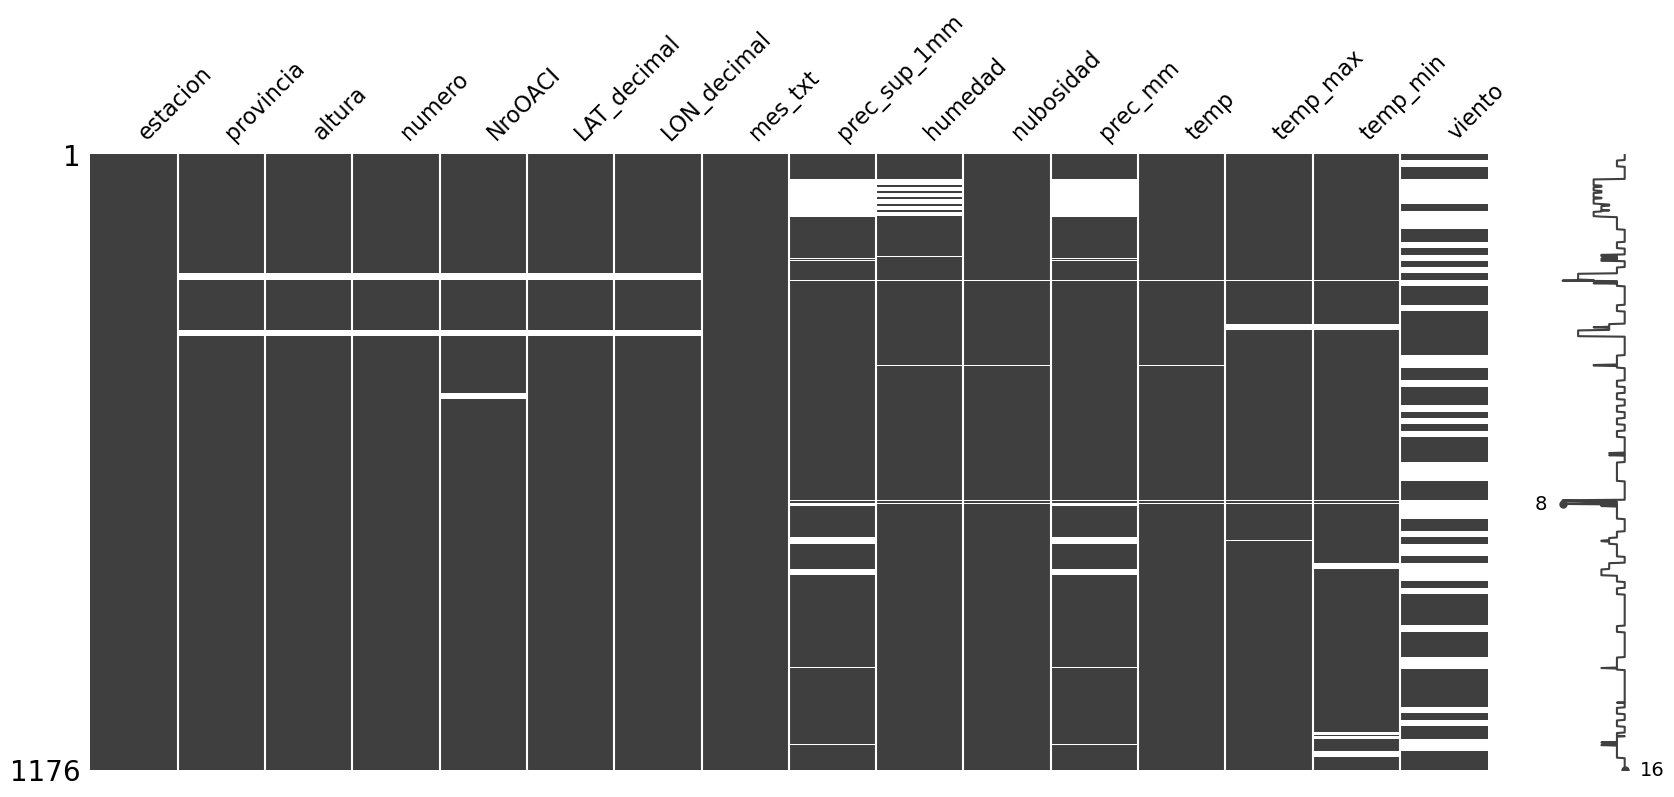

In [43]:
msno.matrix(smn_historico, figsize=(20,8))

### Análisis por columnas

### 1. Provincia

In [ ]:
smn_historico[smn_historico["provincia"].isnull()]

,estacion,provincia,altura,numero,NroOACI,LAT_decimal,LON_decimal,mes_txt,prec_sup_1mm,humedad,nubosidad,prec_mm,temp,temp_max,temp_min,viento
228,CORONEL PRINGLES AERO,NaN,NaN,NaN,NaN,NaN,NaN,Ene,6.4,61.5,3.3,73.9,21.5,29.3,13.7,10.8
229,CORONEL PRINGLES AERO,NaN,NaN,NaN,NaN,NaN,NaN,Feb,6.4,68.7,3.5,91.5,19.9,27.5,13.0,9.3
230,CORONEL PRINGLES AERO,NaN,NaN,NaN,NaN,NaN,NaN,Mar,6.6,74.4,3.5,81.9,17.5,24.9,11.0,9.1
231,CORONEL PRINGLES AERO,NaN,NaN,NaN,NaN,NaN,NaN,Abr,5.6,76.1,3.7,62.9,13.2,20.4,7.3,8.0
232,CORONEL PRINGLES AERO,NaN,NaN,NaN,NaN,NaN,NaN,May,4.6,79.5,4.3,37.9,9.9,16.4,4.8,8.3
233,CORONEL PRINGLES AERO,NaN,NaN,NaN,NaN,NaN,NaN,Jun,3.3,77.5,4.2,22.5,7.1,13.3,1.9,10.2
234,CORONEL PRINGLES AERO,NaN,NaN,NaN,NaN,NaN,NaN,Jul,4.1,76.4,4.3,37.0,6.2,12.5,1.1,9.7
235,CORONEL PRINGLES AERO,NaN,NaN,NaN,NaN,NaN,NaN,Ago,4.1,72.9,4.1,38.3,7.8,14.9,2.2,10.3
236,CORONEL PRINGLES AERO,NaN,NaN,NaN,NaN,NaN,NaN,Sep,5.5,71.4,4.1,50.6,10.1,17.2,3.5,10.0
237,CORONEL PRINGLES AERO,NaN,NaN,NaN,NaN,NaN,NaN,Oct,7.6,71.5,4.2,93.2,13.4,20.0,6.8,9.8


#### 2. Viento

In [10]:
smn_historico.viento.describe()

count    708.000000
mean      13.011582
std        5.554040
min        3.900000
25%        9.200000
50%       11.800000
75%       15.900000
max       36.500000
Name: viento, dtype: float64

In [11]:
smn_historico.isna().sum()

estacion          0
provincia        24
altura           24
numero           24
NroOACI          36
LAT_decimal      24
LON_decimal      24
mes_txt           0
prec_sup_1mm    115
humedad          66
nubosidad        10
prec_mm         115
temp              9
temp_max         18
temp_min         52
viento          468
dtype: int64

In [ ]:
smn_historico.prec_sup_1mm.describe()

count    1061.000000
mean       68.234873
std        51.674519
min         0.000000
25%        23.300000
50%        58.900000
75%       106.500000
max       277.900000
Name: prec_mm, dtype: float64

In [15]:
smn_historico.prec_mm.describe()

count    1061.000000
mean       68.234873
std        51.674519
min         0.000000
25%        23.300000
50%        58.900000
75%       106.500000
max       277.900000
Name: prec_mm, dtype: float64

In [19]:
smn_historico[smn_historico["prec_mm"]==0]

,estacion,provincia,altura,numero,NroOACI,LAT_decimal,LON_decimal,mes_txt,prec_sup_1mm,humedad,nubosidad,prec_mm,temp,temp_max,temp_min,viento
497,LA QUIACA OBSERVATORIO,JUJUY,3459.0,87007.0,SASQ,-22.1,-65.6,Jun,0.0,27.4,1.4,0.0,4.8,16.3,-5.7,5.5
498,LA QUIACA OBSERVATORIO,JUJUY,3459.0,87007.0,SASQ,-22.1,-65.6,Jul,0.0,25.7,1.3,0.0,4.5,16.1,-6.2,5.9



# Conclusiones

# 1

Viento es la columna con más cantidad de nulos: 468, creemos puede ser que 39 estaciones no tienen sensor de viento.

# 2

Tanto `prec_mm` como `prec_sup_1mm` tienen 115 datos nulos, nuestra hipótesis es que los nulos se refieren a precipitación 0.

# 3
Los nulos de provincia, altura, número, latitud decimal y longitud decimal, que son en total 24, es porque hay dos estaciones que no tienen cargados esos datos.
- CORONEL PRINGLES AERO	
- EL TREBOL

